# Methods comparison: NFG-SS vs SVRS vs FedAvg

Pulls the W&B runs for each method, clips to the requested epoch budget so all three end at the same total transmitted vectors, and plots **test accuracy** on a single figure.  Multiple seed URLs per method are aggregated into a center curve with a shaded cross-seed band (median + min/max by default; switch to mean ± std via `BAND`).

Per-epoch vector budgets for our setup (1 server + 10 clients, $B=1$):

| Method   | Vectors / epoch |
|----------|-----------------|
| NFG-SS   | 40 (4 vectors per inner step, K=10 inner steps) |
| SVRS     | 40 (20 anchor refresh + 20 inner-loop expectation) |
| FedAvg   | 20 (2 vectors per round, 10 rounds) |

In [1]:
from __future__ import annotations

import os
import re
from dataclasses import dataclass
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import pandas as pd

## Run configuration

In [2]:
@dataclass
class RunSpec:
    label: str
    urls: list[str]              # one URL per seed; len==1 → no band drawn
    algo_namespace: str          # "<algo>/<metric>" key prefix
    vectors_per_epoch: int       # cost on x-axis
    max_epoch: int               # clip the run at this epoch (1-indexed)
    color: str
    marker: str


RUNS: list[RunSpec] = [
    RunSpec(
        label="NFG-SS (ours)",
        urls=[
            "https://wandb-radfan.ru/chirkov/similarity-sarah/runs/93gffsfn",
            "https://wandb-radfan.ru/chirkov/similarity-sarah/runs/yup9ccfu",
            "https://wandb-radfan.ru/chirkov/similarity-sarah/runs/7cy8jpq9",
        ],
        algo_namespace="batched_nfg_sarah",
        vectors_per_epoch=40,
        max_epoch=50,
        color="#d95f02",
        marker="s",
    ),
    RunSpec(
        label="SVRS",
        urls=[
            "https://wandb-radfan.ru/chirkov/svrs/runs/apvzva47",
            "https://wandb-radfan.ru/chirkov/svrs/runs/2nnaeyxc",
            "https://wandb-radfan.ru/chirkov/svrs/runs/tf59a1tn",
        ],
        algo_namespace="svrs",
        vectors_per_epoch=40,
        max_epoch=50,
        color="#1f78b4",
        marker="o",
    ),
    RunSpec(
        label="FedAvg",
        urls=[
            "https://wandb-radfan.ru/chirkov/similarity-sarah/runs/pj2p1eyd",
            "https://wandb-radfan.ru/chirkov/similarity-sarah/runs/t9clk75k",
            "https://wandb-radfan.ru/chirkov/similarity-sarah/runs/mq6ndgqc",
        ],
        algo_namespace="fedavg",
        vectors_per_epoch=20,
        max_epoch=100,
        color="#7570b3",
        marker="^",
    ),
]

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Cross-seed aggregation:
#   "minmax" — solid line = median across seeds, shaded = min/max envelope
#              (recommended for k=3..5 seeds: makes no distributional
#              assumption, honestly shows worst case).
#   "std"    — solid line = mean across seeds, shaded = mean ± STD_K·std
#              (more familiar but assumes near-normality).
BAND = "minmax"
STD_K = 1.0

## W&B helpers

In [3]:
def parse_run_url(url: str) -> tuple[str, str, str, str]:
    parsed = urlparse(url)
    host = f"{parsed.scheme}://{parsed.netloc}"
    parts = [p for p in parsed.path.split("/") if p]
    if len(parts) < 4 or parts[2] != "runs":
        raise ValueError(f"Unexpected W&B run URL shape: {url!r}")
    entity, project, _, run_id = parts[:4]
    return host, entity, project, run_id


def fetch_run_history(url: str):
    host, entity, project, run_id = parse_run_url(url)
    os.environ["WANDB_BASE_URL"] = host
    import wandb

    api = wandb.Api()
    run = api.run(f"{entity}/{project}/{run_id}")
    hist = run.history(samples=100_000, pandas=True)
    print(f"  {entity}/{project}/{run_id}: {len(hist)} rows")
    return run, hist

## Curve extraction

`metric` is the part *after* the algorithm namespace — e.g. `"test/accuracy"`, `"test/loss"`, `"val/accuracy"`, or any other key the runner logs (see `metrics_logger.py`).

In [4]:
def find_metric_column(hist: pd.DataFrame, algo_namespace: str, metric: str) -> str:
    """Locate the column for ``<algo>/<metric>``."""
    primary = f"{algo_namespace}/{metric}"
    if primary in hist.columns:
        return primary
    pat = re.compile(rf"(^|/){re.escape(metric)}$")
    for c in hist.columns:
        if pat.search(c):
            return c
    raise SystemExit(
        f"No '{metric}' column found for {algo_namespace}. "
        f"Available: {sorted(hist.columns)}"
    )


def _extract_one_seed(url: str, spec: RunSpec, metric: str) -> pd.DataFrame:
    _, hist = fetch_run_history(url)
    col = find_metric_column(hist, spec.algo_namespace, metric)
    sub = hist[["_step", col]].dropna().rename(
        columns={"_step": "epoch", col: "value"}
    )
    sub["epoch"] = sub["epoch"].astype(int)
    sub = sub.sort_values("epoch")
    sub = sub[sub["epoch"] <= spec.max_epoch].copy()
    return sub[["epoch", "value"]]


def extract_curve(spec: RunSpec, metric: str = "test/accuracy") -> pd.DataFrame:
    """Aggregate metric across seeds.

    Returns columns: label, epoch, vectors, center, lo, hi, n_seeds.
    """
    print(f"[{spec.label}] {len(spec.urls)} seed(s)")
    per_seed = [_extract_one_seed(u, spec, metric) for u in spec.urls]
    long = pd.concat(
        [df.assign(seed=i) for i, df in enumerate(per_seed)],
        ignore_index=True,
    )
    grouped = long.groupby("epoch")["value"]
    median = grouped.median()
    mean, std = grouped.mean(), grouped.std().fillna(0.0)
    lo_min, hi_max = grouped.min(), grouped.max()
    n_seeds = grouped.size()

    if BAND == "std":
        center, lo, hi = mean, mean - STD_K * std, mean + STD_K * std
    else:  # "minmax"
        center, lo, hi = median, lo_min, hi_max

    out = pd.DataFrame({
        "epoch": center.index.astype(int),
        "center": center.values,
        "lo": lo.values,
        "hi": hi.values,
        "n_seeds": n_seeds.values,
    })
    out["vectors"] = out["epoch"] * spec.vectors_per_epoch
    out["label"] = spec.label
    print(
        f"  → kept {len(out)} epochs; seeds/epoch: "
        f"{int(out['n_seeds'].min())}…{int(out['n_seeds'].max())}; "
        f"center range [{out['center'].min():.3f}, {out['center'].max():.3f}]"
    )
    return out[["label", "epoch", "vectors", "center", "lo", "hi", "n_seeds"]]


def build_curves(specs: list[RunSpec], metric: str = "test/accuracy") -> dict[str, pd.DataFrame]:
    return {spec.label: extract_curve(spec, metric=metric) for spec in specs}

## Plotting

`plot` is parameterized: pass any `metric` via `build_curves`, then provide the matching `ylabel` (and optional `ylim`) to `plot`.

In [ ]:
def plot(
    curves: dict[str, pd.DataFrame],
    specs: list[RunSpec],
    *,
    ylabel: str,
    ylim: tuple[float, float] | None = None,
    xlabel: str = "# transmitted vectors",
    out_png: Path | None = None,
    target_markers: int = 10,
    band_alpha: float = 0.20,
) -> None:
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 14,            # base font (affects fallback for everything)
        "axes.labelsize": 17,       # x/y axis label size  ("Test accuracy", "Transmitted vectors")
        "legend.fontsize": 14,      # legend entry text size
        "xtick.labelsize": 14,      # numbers on the X axis
        "ytick.labelsize": 14,      # numbers on the Y axis
    })

    fig, ax = plt.subplots(figsize=(6.0, 4.2))

    for spec in specs:
        df = curves.get(spec.label)
        if df is None or df.empty:
            continue
        markevery = max(1, len(df) // target_markers)

        if (df["n_seeds"] > 1).any() and (df["hi"] > df["lo"]).any():
            ax.fill_between(
                df["vectors"], df["lo"], df["hi"],
                color=spec.color, alpha=band_alpha, linewidth=0,
            )

        ax.plot(
            df["vectors"], df["center"],
            label=spec.label,
            color=spec.color,
            marker=spec.marker,
            markevery=markevery,
            markersize=6,
            markeredgecolor="black",
            markeredgewidth=0.6,
            linewidth=1.8,
            alpha=0.95,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", alpha=0.3)
    if ylim is not None:
        ax.set_ylim(*ylim)

    legend = ax.legend(
        loc="best",
        frameon=True,
        framealpha=0.95,
        edgecolor="0.6",
        fancybox=False,
    )
    legend.get_frame().set_linewidth(0.8)

    fig.tight_layout()

    if out_png is not None:
        out_png.parent.mkdir(parents=True, exist_ok=True)
        # PNG — print-quality raster (300 dpi is the journal standard;
        # bump to 600 for poster prints).  bbox_inches="tight" trims the
        # surrounding whitespace, which makes the PDF version embed
        # cleanly into the LaTeX figure.
        fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.05)
        # PDF — vector, no dpi needed; matplotlib handles fonts as text.
        fig.savefig(
            out_png.with_suffix(".pdf"),
            bbox_inches="tight", pad_inches=0.05,
        )
        print(f"Saved → {out_png} (and {out_png.with_suffix('.pdf').name})")

    plt.show()

## Test accuracy

Solid line: per-epoch median (`BAND="minmax"`) or mean (`BAND="std"`) across seeds.  Shaded region: cross-seed min/max envelope or mean ± `STD_K`·std, respectively.  Drawn only when more than one seed is available.

[NFG-SS (ours)] 3 seed(s)


  chirkov/similarity-sarah/93gffsfn: 50 rows


  chirkov/similarity-sarah/yup9ccfu: 50 rows


  chirkov/similarity-sarah/7cy8jpq9: 50 rows
  → kept 50 epochs; seeds/epoch: 3…3; center range [0.277, 0.799]
[SVRS] 3 seed(s)


  chirkov/svrs/apvzva47: 100 rows


...

  chirkov/svrs/tf59a1tn: 46 rows
  → kept 50 epochs; seeds/epoch: 2…3; center range [0.280, 0.739]
[FedAvg] 3 seed(s)


  chirkov/similarity-sarah/pj2p1eyd: 150 rows


  chirkov/similarity-sarah/t9clk75k: 150 rows


  chirkov/similarity-sarah/mq6ndgqc: 150 rows
  → kept 100 epochs; seeds/epoch: 3…3; center range [0.100, 0.717]


Saved → ../figures/methods_comparison_accuracy.png (and methods_comparison_accuracy.pdf)


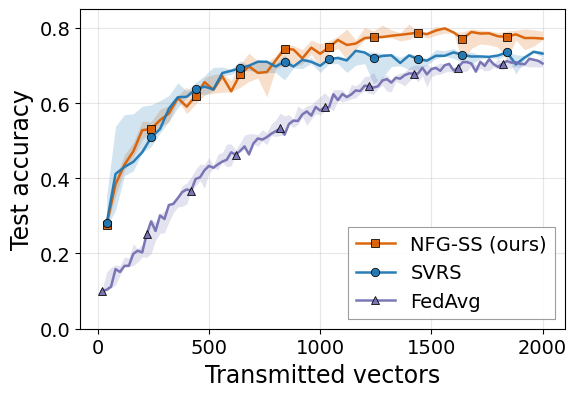

In [6]:
acc_curves = build_curves(RUNS, metric="test/accuracy")
plot(
    acc_curves, RUNS,
    ylabel="Test accuracy",
    ylim=(0.0, 0.85),
    out_png=FIGURES_DIR / "methods_comparison_accuracy.png",
)